In [2]:
import itertools
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import pymc3 as pm
from scipy.stats import vonmises
from scipy.special import i0

from insilico_stimuli.stimuli import GaborSet, CenterSurround

seed = 42
rng = default_rng(seed=seed)
torch.manual_seed(seed=seed)
EPSILON = 1e-12
mpl.style.use("seaborn")
sns.set_palette("colorblind")
sns.set_context("paper")
sns.set_style("darkgrid")
mpl.style.use("seaborn")


In [2]:
def plot_correlation(trace):
    fig, ax = plt.subplots(dpi=100)
    sns.heatmap(np.corrcoef(trace["neuron"].T), ax=ax, cmap="seismic")
    # make it a square plot
    ax.set_aspect("equal")
    # reduce the tick size
    ax.tick_params(axis='both', which='major', labelsize=9)

In [3]:
def vonmises_pdf(x, mu, kappa):
    return np.exp(kappa * np.cos(x - mu)) / (2 * np.pi * i0(kappa))

In [4]:
def plot_samples(trace, valid_gabors):
    # share x only for 1st row of subplots
    fig, axs = plt.subplots(nrows=2, ncols=5, dpi=150, sharex="row", sharey="row")
    for idx, ax in enumerate(axs[0]):
        response = trace["neuron"][:, idx]
        response_mean = np.mean(trace['neuron'][:, idx].ravel())
        color = "blue" if response_mean < 0.3 else "red"
        sns.histplot(response.ravel(), color=color, stat="probability", element="step", ax=ax)
        ax.text(0.05, 0.95, idx+1, fontsize=6, transform=ax.transAxes)
        ax.text(0.7, 0.95, f"{response_mean:.2f}", fontsize=6, transform=ax.transAxes)
        ax.tick_params(axis='both', which='major', labelsize=5)
        # reduce the font size of the x and y labels
        ax.xaxis.label.set_size(5)
        ax.yaxis.label.set_size(5)
    for idx, ax in enumerate(axs[1]):
        ax.imshow(valid_gabors[idx], cmap="gray", vmin=-1, vmax=1)
        ax.axis("off")
        

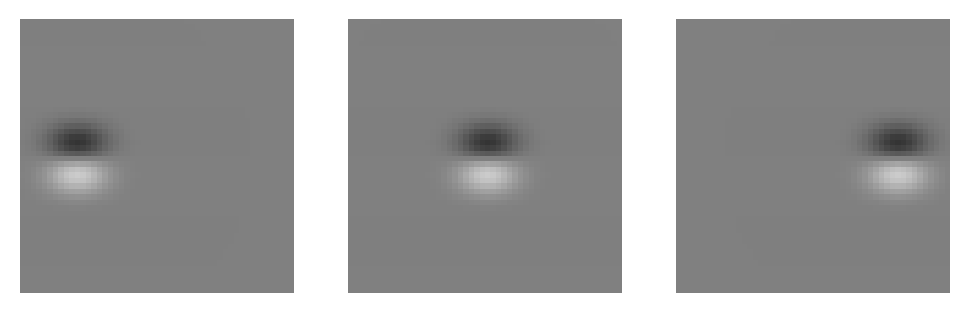

In [3]:
gabor_locations = [(10, 25), (25, 25), (40, 25)]
gabor_params = {
    "canvas_size"         : [50, 50],
    "sizes"               : [15],
    "spatial_frequencies" : [1/20],
    "contrasts"           : [1.0],
    "grey_levels"         : [0.0],
    "eccentricities"      : [0.0],
    "locations"           : gabor_locations,
    "orientations"        : [np.pi/2],  
    "phases"              : [np.pi/2],
    "relative_sf"         : False
}

gabor_set = GaborSet(**gabor_params)
fig, axs = plt.subplots(nrows=1, ncols=3, dpi=200)
for idx, ax in enumerate(axs.ravel()):
    gabor = gabor_set.images()[idx]
    ax.imshow(gabor, cmap='gray', vmin=-1, vmax=1)
    ax.axis("off")

(-0.5, 49.5, 49.5, -0.5)

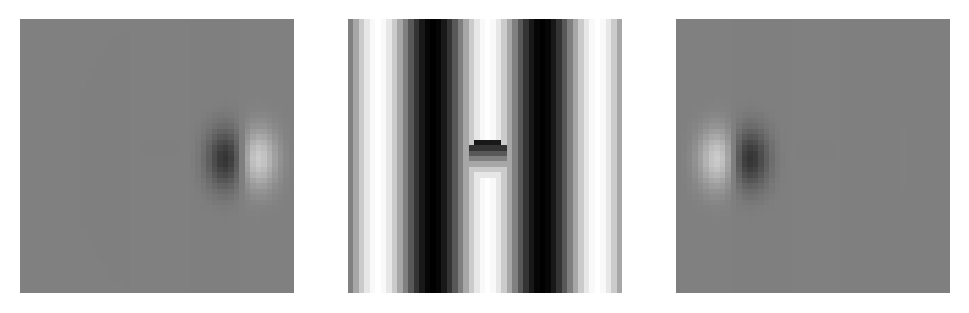

In [4]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1/20],
    "phases_center": gabor_params["phases"],
    "phases_surround": [np.pi/2 + 2*np.pi*1/20*(25-10)],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi/2],
    "orientations_surround": [0.],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15/4/50],
    "sizes_surround": [15/4/50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

center_cut = CenterSurround(**center_surround_params)

U, V = np.meshgrid(np.arange(50), np.arange(50))
XX = np.stack((U, V), axis=-1)
gauss_mask_right = np.exp(-np.sum((XX - np.array([40, 25]))**2, axis=-1) / (15/4)**2 / 2)
gauss_mask_left = np.exp(-np.sum((XX - np.array([10, 25]))**2, axis=-1) / (15/4)**2 / 2)

fig, axs = plt.subplots(nrows=1, ncols=3, dpi=200)
axs[0].imshow(center_cut.images()[0]*gauss_mask_right, cmap="gray", vmin=-1, vmax=1)
axs[0].axis("off")
axs[1].imshow(center_cut.images()[0], cmap="gray", vmin=-1, vmax=1)
axs[1].axis("off")
axs[2].imshow(center_cut.images()[0]*gauss_mask_left, cmap="gray", vmin=-1, vmax=1)
axs[2].axis("off")
# plt.imshow(center_cut.images()[0] * gauss_mask, cmap="gray", vmin=-1, vmax=1)
# plt.imshow(center_cut.images()[0], cmap="gray", vmin=-1, vmax=1)

plt.axis("off")

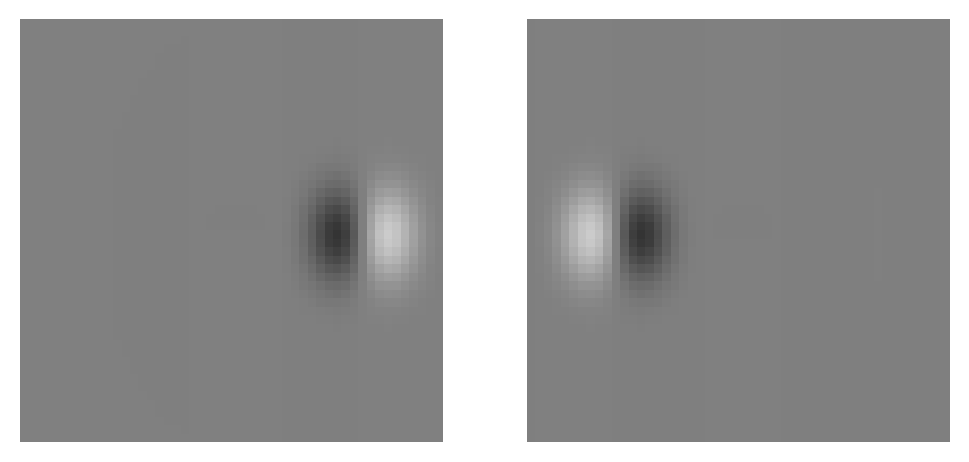

In [5]:
surround_right = center_cut.images()[0]*gauss_mask_right
surround_left = center_cut.images()[0]*gauss_mask_left
surround_filters = np.stack((surround_right, surround_left))
fig, axs = plt.subplots(ncols=2, dpi=200)
for idx, ax in enumerate(axs.ravel()):
    ax.imshow(surround_filters[idx], cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")

In [6]:
valid_gabors = np.concatenate((gabor_set.images(), surround_filters))

In [10]:
orientations = np.array([0., 0., 0., np.pi/2, np.pi/2])
np.save("/src/project/computed/center_masked_surround_gabors_orientations.npy", orientations)

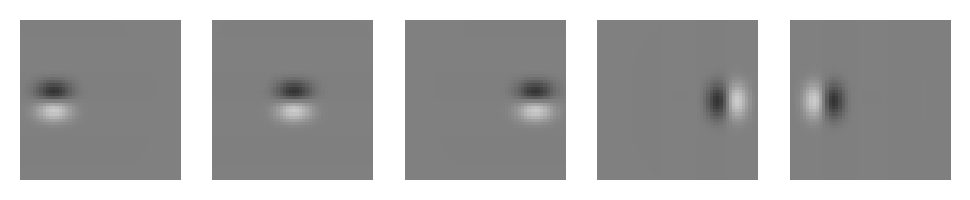

In [7]:
fig, axs = plt.subplots(nrows=1, ncols=5, dpi=200)
for idx, ax in enumerate(axs.ravel()):
    gabor = valid_gabors[idx]
    ax.imshow(gabor, cmap='gray', vmin=-1, vmax=1)
    ax.axis("off")

In [11]:
a = np.random.randn(2, 4, 5)

In [13]:
torch.tensor(a).permute(1, 2, 0).shape, a.transpose(1, 2, 0).shape

(torch.Size([4, 5, 2]), (4, 5, 2))

In [10]:
valid_gabors.shape, torch.tensor(valid_gabors).permute(1, 2, 0).shape

((5, 50, 50), torch.Size([50, 50, 5]))

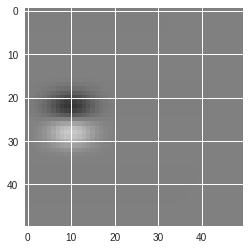

In [11]:
plt.imshow(valid_gabors[0], cmap="gray", vmin=-1, vmax=1)

In [12]:
def sample_posterior(stimulus, vonmises_kappa=1., n_samples=1000):
    vonmises_loc = 0.
    n_neurons = len(valid_gabors)
    stimulus_sigma = torch.abs(torch.rand(1)) + EPSILON
    model = pm.Model()
    with model:
        o = pm.Uniform("orientation", lower=0, upper=np.pi)
        z = pm.Exponential(
            "neuron", 
            lam=vonmises_pdf(o - [np.pi/2, np.pi/2, np.pi/2, 0., 0.], vonmises_loc, vonmises_kappa),
            shape=n_neurons
        )
        x = pm.Normal("stimulus", mu=torch.tensor(valid_gabors).permute(1, 2, 0) @ z, sigma=stimulus_sigma, observed=stimulus)
        trace = pm.sample(n_samples, return_inferencedata=False)
    return trace

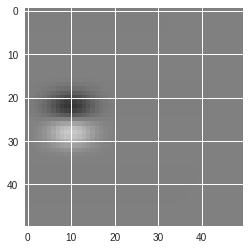

In [14]:
plt.imshow(valid_gabors[0], cmap="gray", vmin=-1, vmax=1)

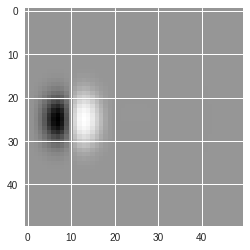

In [15]:
plt.imshow(torch.tensor(valid_gabors)[-1])

(-0.5, 49.5, 49.5, -0.5)

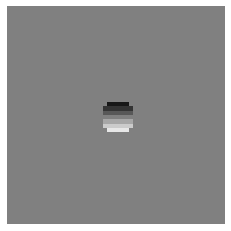

In [8]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1/20],
    "phases_center": gabor_params["phases"],
    "phases_surround": [np.pi/2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi/2],
    "orientations_surround": [0.],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15/4/50],
    "sizes_surround": [15/4/50],
    "contrasts_center": [1.0],
    "contrasts_surround": [0],
}

center_cut = CenterSurround(**center_surround_params)

plt.imshow(center_cut.images()[0], cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

In [9]:
center_cut_stimulus = center_cut.images()[0]

In [ ]:
center_trace = sample_posterior(center_cut.images()[0])

In [ ]:
plot_samples(center_trace, valid_gabors)

(-0.5, 49.5, 49.5, -0.5)

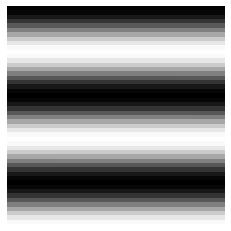

In [10]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": [1/20],
    "spatial_frequencies_surround": [1/20],
    "phases_center": [np.pi/2],
    "phases_surround": [np.pi/2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi/2],
    "orientations_surround": [np.pi/2],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15/4/50],
    "sizes_surround": [15/4/50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

congruent = CenterSurround(**center_surround_params).images()[0]
plt.imshow(congruent, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")


In [11]:
congruent_stimulus = congruent

In [ ]:
congruent_trace = sample_posterior(congruent)


In [ ]:
plot_samples(congruent_trace, valid_gabors)

(-0.5, 49.5, 49.5, -0.5)

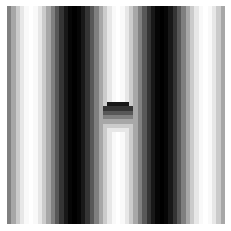

In [12]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1/20],
    "phases_center": gabor_params["phases"],
    "phases_surround": [np.pi/2 + 2*np.pi*1/20*(25-10)],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi/2],
    "orientations_surround": [0.],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15/4/50],
    "sizes_surround": [15/4/50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

incongruent = CenterSurround(**center_surround_params).images()[0]
plt.imshow(incongruent, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

In [24]:
stimuli = np.array([center_cut_stimulus, congruent_stimulus, incongruent])

In [25]:
np.save("/src/project/computed/center_cut_congruent_incongruent.npy", stimuli)

In [13]:
incongruent_trace = sample_posterior(incongruent)


NameError: name 'sample_posterior' is not defined

In [14]:
plot_samples(incongruent_trace, valid_gabors)

NameError: name 'incongruent_trace' is not defined

In [ ]:
# plot a seaborn histogram using kdeplot for all traces with labels
# fill the kde plots with the same color
fig, ax = plt.subplots(dpi=200)
sns.kdeplot(center_trace["neuron"][:, 1].ravel(), linewidth=2, shade=True, label="MEI")
sns.kdeplot(congruent_trace["neuron"][:, 1].ravel(), linewidth=2, shade=True, label="Congruent")
sns.kdeplot(incongruent_trace["neuron"][:, 1].ravel(), linewidth=2, shade=True, label="Incongruent")
# sns.kdeplot(surround_only_trace["neuron"][:, -2].ravel(), linewidth=2, shade=True, label="Surround only")
# sns.kdeplot(surround_moat_trace["neuron"][:, -2].ravel(), linewidth=2, shade=True, label="Surround moat")
sns.kdeplot(center_trace["neuron"][:, -1].ravel(), linewidth=2, shade=True, label="Base")
# label the x axis with "firing rate"
ax.set_xlabel("Mean firing rate")
# move the legend to the top center
plt.legend(prop={'size': 10}, title='Stimulus', title_fontsize=12, loc="upper center")